# Task 4: Standardization and Normalization
**Data Science in Cybersecurity – Practical Assignment**

This notebook standardizes categorical values and applies normalization to numerical features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load output from Task 3
df = pd.read_csv('cybersecurity_task3.csv')
print(f'Loaded dataset shape: {df.shape}')
df.head()

Loaded dataset shape: (437, 17)


,flow_id,src_ip,src_port,dst_ip,dst_port,protocol,timestamp,flow_duration,tot_fwd_pkts,tot_bwd_pkts,pkt_size_avg,fwd_iat_mean,bwd_iat_mean,flow_bytes/s,flow_pkts/s,flag,label
0,flow_0000,7.140.125.58,99999,171.84.26.102,22,Tcp,2024-01-03 10:47:07,NaN,212.0,140.0,527.75,2154.51,2757.13,819791.08,103.97,ACK,PortScan
1,flow_0001,27.44.216.9,51191,161.156.119.110,8080,Tcp,2024-01-19 14:55:33,NaN,-5.0,NaN,374.60,3870.88,1352.54,424592.44,708.53,SYN,benign
2,flow_0003,130.13.101.184,99999,55.244.39.34,22,HTTP,2024-01-20 00:36:58,-999.0,NaN,264.0,1463.45,374.99,3251.68,740429.12,518.97,FIN,ddos
3,flow_0004,140.214.112.115,51228,152.115.227.3,21,UDP,01-29-2024 22:31:54,9999999.0,NaN,452.0,1213.28,3138.95,1517.09,221694.04,382.59,FIN,benign
4,flow_0005,208.3.81.179,16796,3.175.61.253,8080,tcp,01-22-2024 15:26:12,44392.0,300.0,NaN,99999.90,4023.63,4857.33,767843.93,590.34,SYN,Brute Force


## 4.1 – Standardize Categorical Values

Categorical columns (`protocol`, `flag`, `label`) may have mixed casing (e.g. `tcp`, `TCP`, `Tcp`) or label inconsistencies (`benign` vs `BENIGN`). We unify them.

In [2]:
# ── Before: inspect unique values ────────────────────────────────────────
for col in ['protocol', 'flag', 'label']:
    print(f'{col}: {df[col].unique()}')

protocol: <StringArray>
['Tcp', 'HTTP', 'UDP', 'tcp', 'TCP', 'ICMP', nan, 'udp']
Length: 8, dtype: str
flag: <StringArray>
['ACK', 'SYN', 'FIN', 'RST', 'PSH', nan]
Length: 6, dtype: str
label: <StringArray>
['PortScan', 'benign', 'ddos', 'Brute Force', 'DDoS', 'BENIGN']
Length: 6, dtype: str


In [3]:
df_std = df.copy()

# ── Standardize protocol: uppercase ──────────────────────────────────────
df_std['protocol'] = df_std['protocol'].str.strip().str.upper()

# ── Standardize flag: uppercase ───────────────────────────────────────────
df_std['flag'] = df_std['flag'].str.strip().str.upper()

# ── Standardize label: uppercase, then map to clean canonical labels ──────
df_std['label'] = df_std['label'].str.strip().str.upper()

# Canonical label mapping (merge variants)
label_map = {
    'BENIGN':      'BENIGN',
    'PORTSCAN':    'PORTSCAN',
    'DDOS':        'DDOS',
    'BRUTE FORCE': 'BRUTEFORCE',
    'BRUTEFORCE':  'BRUTEFORCE',
}
df_std['label'] = df_std['label'].map(label_map).fillna(df_std['label'])

print('After standardization:')
for col in ['protocol', 'flag', 'label']:
    print(f'  {col}: {sorted(df_std[col].dropna().unique())}')

After standardization:
  protocol: ['HTTP', 'ICMP', 'TCP', 'UDP']
  flag: ['ACK', 'FIN', 'PSH', 'RST', 'SYN']
  label: ['BENIGN', 'BRUTEFORCE', 'DDOS', 'PORTSCAN']


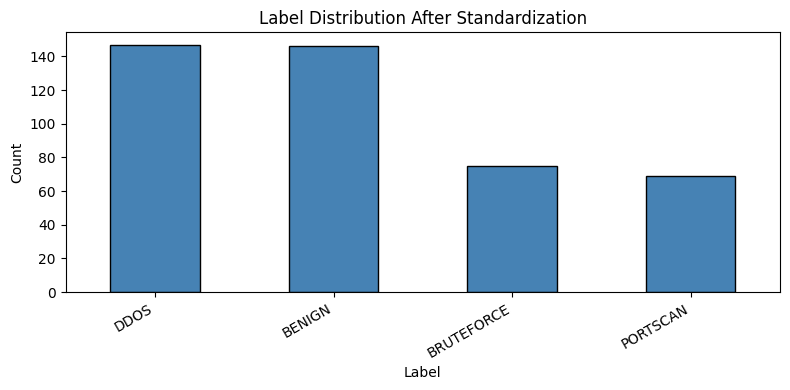

In [4]:
# Distribution of labels after standardization
fig, ax = plt.subplots(figsize=(8, 4))
df_std['label'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Label Distribution After Standardization')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task4_label_distribution.png', dpi=150)
plt.show()

## 4.2 – Correct Invalid Port Values

Valid port range: 0–65535. Values of `-1` or `99999` seen in the raw data are placeholders/errors.

In [5]:
# Flag invalid ports
invalid_src = df_std[(df_std['src_port'] < 0) | (df_std['src_port'] > 65535)]
invalid_dst = df_std[(df_std['dst_port'] < 0) | (df_std['dst_port'] > 65535)]
print(f'Invalid src_port rows: {len(invalid_src)}')
print(f'Invalid dst_port rows: {len(invalid_dst)}')

# Replace with NaN, then impute with median
df_std['src_port'] = df_std['src_port'].where(
    (df_std['src_port'] >= 0) & (df_std['src_port'] <= 65535), np.nan
)
df_std['dst_port'] = df_std['dst_port'].where(
    (df_std['dst_port'] >= 0) & (df_std['dst_port'] <= 65535), np.nan
)

df_std['src_port'].fillna(df_std['src_port'].median(), inplace=True)
df_std['dst_port'].fillna(df_std['dst_port'].median(), inplace=True)

df_std['src_port'] = df_std['src_port'].round().astype(int)
df_std['dst_port'] = df_std['dst_port'].round().astype(int)
print('Invalid ports replaced with median.')

Invalid src_port rows: 295
Invalid dst_port rows: 0


/tmp/ipykernel_12933/1946791827.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_std['src_port'].fillna(df_std['src_port'].median(), inplace=True)
/tmp/ipykernel_12933/1946791827.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inpla

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

## 4.3 – Normalize Numerical Features

Two common techniques:
- **Min-Max Scaling** → scales to [0, 1]; good for bounded features
- **Z-score Standardization** → mean=0, std=1; good for ML algorithms assuming Gaussian input

We apply **Min-Max** here (common in network traffic analysis) and keep a Z-score copy for reference.

In [6]:
numeric_features = [
    'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts',
    'pkt_size_avg', 'fwd_iat_mean', 'bwd_iat_mean',
    'flow_bytes/s', 'flow_pkts/s'
]

# Only scale columns that actually exist
existing_feats = [c for c in numeric_features if c in df_std.columns]
print(f'Scaling columns: {existing_feats}')

Scaling columns: ['flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'pkt_size_avg', 'fwd_iat_mean', 'bwd_iat_mean', 'flow_bytes/s', 'flow_pkts/s']


In [7]:
# ── Min-Max Scaling ───────────────────────────────────────────────────────
minmax_scaler = MinMaxScaler()
df_minmax = df_std.copy()
df_minmax[existing_feats] = minmax_scaler.fit_transform(df_std[existing_feats])

print('Min-Max scaled descriptive statistics:')
print(df_minmax[existing_feats].describe().round(4))

Min-Max scaled descriptive statistics:
       flow_duration  tot_fwd_pkts  tot_bwd_pkts  pkt_size_avg  fwd_iat_mean  \
count       336.0000      295.0000      239.0000      429.0000      425.0000   
mean          0.3529        0.2224        0.4546        0.0305        0.5025   
std           0.4768        0.3178        0.2902        0.1500        0.2979   
min           0.0000        0.0000        0.0000        0.0000        0.0000   
25%           0.0000        0.0000        0.2110        0.0032        0.2639   
50%           0.0058        0.0000        0.4000        0.0075        0.4753   
75%           1.0000        0.4604        0.7110        0.0114        0.7657   
max           1.0000        1.0000        1.0000        1.0000        1.0000   

       bwd_iat_mean  flow_bytes/s  flow_pkts/s  
count      424.0000      415.0000     419.0000  
mean         0.4978        0.5250       0.4890  
std          0.2890        0.2809       0.2931  
min          0.0000        0.0000       0.00

In [8]:
# ── Z-Score Standardization (for reference / ML algorithms) ───────────────
zscore_scaler = StandardScaler()
df_zscore = df_std.copy()
df_zscore[existing_feats] = zscore_scaler.fit_transform(df_std[existing_feats])

print('Z-Score standardized descriptive statistics:')
print(df_zscore[existing_feats].describe().round(4))

Z-Score standardized descriptive statistics:
       flow_duration  tot_fwd_pkts  tot_bwd_pkts  pkt_size_avg  fwd_iat_mean  \
count       336.0000      295.0000      239.0000      429.0000      425.0000   
mean          0.0000        0.0000       -0.0000       -0.0000       -0.0000   
std           1.0015        1.0017        1.0021        1.0012        1.0012   
min          -0.7413       -0.7009       -1.5701       -0.2036       -1.6890   
25%          -0.7413       -0.7009       -0.8414       -0.1822       -0.8021   
50%          -0.7290       -0.7009       -0.1886       -0.1536       -0.0914   
75%           1.3592        0.7504        0.8854       -0.1278        0.8846   
max           1.3592        2.4514        1.8835        6.4703        1.6720   

       bwd_iat_mean  flow_bytes/s  flow_pkts/s  
count      424.0000      415.0000     419.0000  
mean         0.0000        0.0000       0.0000  
std          1.0012        1.0012       1.0012  
min         -1.7243       -1.8714     

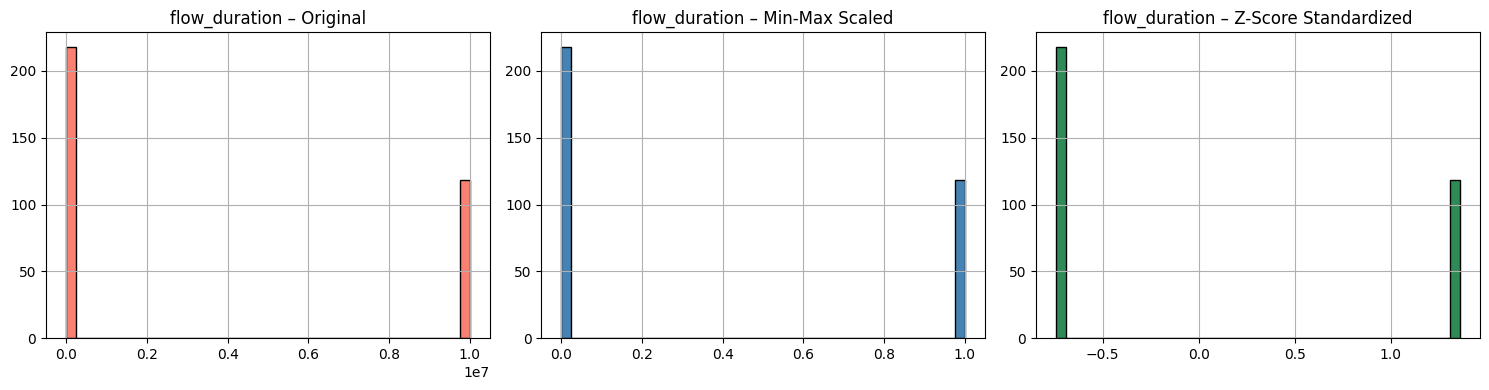

In [9]:
# ── Visual comparison: before vs after scaling for one feature ────────────
feature_to_plot = 'flow_duration'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_std[feature_to_plot].hist(bins=40, ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title(f'{feature_to_plot} – Original')

df_minmax[feature_to_plot].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title(f'{feature_to_plot} – Min-Max Scaled')

df_zscore[feature_to_plot].hist(bins=40, ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title(f'{feature_to_plot} – Z-Score Standardized')

plt.tight_layout()
plt.savefig('task4_normalization_comparison.png', dpi=150)
plt.show()

## 4.4 – Save for Next Task

In [10]:
# Save the Min-Max version as the primary pipeline output
df_minmax.to_csv('cybersecurity_task4.csv', index=False)
print(f'Saved to cybersecurity_task4.csv  |  shape: {df_minmax.shape}')

Saved to cybersecurity_task4.csv  |  shape: (437, 17)
